# VideoPainter Colab

**Runtime:** A100 GPU (40GB)

All fixes integrated. If runtime restarts, just re-run from Cell 1.

## Cell 1: Setup + All Fixes

In [1]:
import os, sys
!nvidia-smi --query-gpu=name,memory.total --format=csv

os.chdir('/content')
if not os.path.exists('/content/VideoPainter'):
    !git clone https://github.com/TencentARC/VideoPainter.git
os.chdir('/content/VideoPainter')

!pip uninstall diffusers -y -q 2>/dev/null
!pip install einops decord scipy imageio imageio-ffmpeg hydra-core iopath omegaconf -q 2>&1 | tail -2

mods_to_remove = [k for k in list(sys.modules.keys()) if k.startswith('diffusers')]
for m in mods_to_remove:
    del sys.modules[m]
for p in ['/content/VideoPainter/diffusers/src', '/content/VideoPainter/app']:
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ['PYTHONPATH'] = '/content/VideoPainter/diffusers/src:/content/VideoPainter/app'

# FIX 1: SAM2 C extension -> scipy
sam2_misc = '/content/VideoPainter/app/sam2/utils/misc.py'
with open(sam2_misc, 'r') as f:
    lines = f.readlines()
start = end = None
for i, line in enumerate(lines):
    if 'def get_connected_components(' in line:
        start = i
    elif start is not None and i > start and (line.startswith('def ') or line.startswith('class ')):
        end = i
        break
if start is not None:
    if end is None: end = len(lines)
    lines[start:end] = ['''def get_connected_components(mask):
    from scipy import ndimage
    import numpy as np
    mask_np = mask.cpu().numpy().astype(np.uint8)
    N, C, H, W = mask_np.shape
    labels_out = np.zeros_like(mask_np, dtype=np.int32)
    counts_out = np.zeros_like(mask_np, dtype=np.int32)
    for n in range(N):
        for c in range(C):
            labeled, num_features = ndimage.label(mask_np[n, c])
            labels_out[n, c] = labeled
            for ii in range(1, num_features + 1):
                counts_out[n, c][labeled == ii] = (labeled == ii).sum()
    return torch.from_numpy(labels_out).to(mask.device), torch.from_numpy(counts_out).to(mask.device)


''']
    with open(sam2_misc, 'w') as f:
        f.writelines(lines)
    print('[FIX 1] SAM2 -> scipy: OK')

# FIX 2: transformers FLAX_WEIGHTS_NAME
!cd /content/VideoPainter && git checkout -- diffusers/src/diffusers/pipelines/pipeline_loading_utils.py
pl = '/content/VideoPainter/diffusers/src/diffusers/pipelines/pipeline_loading_utils.py'
with open(pl, 'r') as f: c = f.read()
c = c.replace('from transformers.utils import FLAX_WEIGHTS_NAME as TRANSFORMERS_FLAX_WEIGHTS_NAME',
              'TRANSFORMERS_FLAX_WEIGHTS_NAME = "flax_model.msgpack"')
with open(pl, 'w') as f: f.write(c)
print('[FIX 2] transformers compat: OK')

# FIX 3: Pipeline offload seq - add branch
pa = '/content/VideoPainter/diffusers/src/diffusers/pipelines/cogvideo/pipeline_cogvideox_inpainting_i2v_branch_anyl.py'
with open(pa, 'r') as f: c = f.read()
c = c.replace('model_cpu_offload_seq = "text_encoder->transformer->vae"',
              'model_cpu_offload_seq = "text_encoder->branch->transformer->vae"')
with open(pa, 'w') as f: f.write(c)
print('[FIX 3] offload seq + branch: OK')

import torch
print(f'\nPyTorch: {torch.__version__} | GPU: {torch.cuda.get_device_name(0)}')
from diffusers import CogVideoXDPMScheduler; print('diffusers: OK')
from sam2.build_sam import build_sam2_video_predictor; print('SAM2: OK')
print('\n=== All setup done ===')

name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB
Cloning into 'VideoPainter'...
remote: Enumerating objects: 889, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 889 (delta 31), reused 21 (delta 21), pack-reused 850 (from 1)
Receiving objects: 100% (889/889), 75.28 MiB | 48.42 MiB/s, done.
Resolving deltas: 100% (315/315), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 148.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.1 MB/s eta 0:00:00
[FIX 1] SAM2 -> scipy: OK
[FIX 2] transformers compat: OK
[FIX 3] offload seq + branch: OK

PyTorch: 2.10.0+cu128 | GPU: NVIDIA A100-SXM4-40GB
diffusers: OK
SAM2: OK

=== All setup done ===


## Cell 2: Write fixed run_demo.py

In [2]:
with open('/content/VideoPainter/run_demo.py', 'w') as f:
    f.write('''import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import sys, argparse, numpy as np, torch, cv2
from PIL import Image
from decord import VideoReader

def extract_frames(video_path, target_fps=8, max_seconds=6, target_h=480, target_w=720):
    print(f"[1/5] Loading video: {video_path}")
    vr = VideoReader(video_path)
    fps = vr.get_avg_fps()
    total = len(vr)
    dur = total / fps
    print(f"  Original: {total} frames, {fps:.1f} fps, {dur:.1f}s")
    use_frames = int(min(dur, max_seconds) * fps)
    step = max(1, int(fps / target_fps))
    indices = list(range(0, use_frames, step))
    raw = vr.get_batch(indices).asnumpy()
    frames = np.array([cv2.resize(f, (target_w, target_h)) for f in raw])
    print(f"  Extracted: {len(frames)} frames at {target_fps}fps, {target_h}x{target_w}")
    return frames, target_fps

def create_masks_with_sam2(frames, click_points, click_labels, sam2_checkpoint, model_cfg):
    print("[2/5] Running SAM2...")
    from sam2.build_sam import build_sam2_video_predictor
    predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint)
    state = predictor.init_state(images=frames, offload_video_to_cpu=True, async_loading_frames=True)
    predictor.reset_state(state)
    pts = np.array(click_points, dtype=np.float32)
    lbls = np.array(click_labels, dtype=np.int32)
    _, _, logits = predictor.add_new_points(inference_state=state, frame_idx=0, obj_id=0, points=pts, labels=lbls)
    m0 = (logits[0,0]>0).cpu().numpy()
    print(f"  First frame mask: {m0.sum()} px ({100*m0.sum()/(m0.shape[0]*m0.shape[1]):.1f}%)")
    masks = np.zeros((len(frames), frames.shape[1], frames.shape[2]), dtype=np.uint8)
    for fi, _, ml in predictor.propagate_in_video(state):
        masks[fi] = (ml[0,0]>0).cpu().numpy().astype(np.uint8)
    print(f"  Done! shape: {masks.shape}")
    return masks

def save_visualization(frames, masks, output_dir, click_points=None):
    print("[3/5] Saving visualization...")
    os.makedirs(output_dir, exist_ok=True)
    f0 = frames[0].copy()
    if click_points:
        for pt in click_points:
            cv2.circle(f0, (int(pt[0]),int(pt[1])), 8, (0,255,0), -1)
            cv2.circle(f0, (int(pt[0]),int(pt[1])), 8, (255,255,255), 2)
    ov = f0.copy(); ov[masks[0]>0] = [255,0,0]
    cv2.imwrite(os.path.join(output_dir,"frame0_with_mask.png"), cv2.cvtColor(cv2.addWeighted(f0,0.6,ov,0.4,0), cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(output_dir,"mask0.png"), masks[0]*255)
    cv2.imwrite(os.path.join(output_dir,"frame0_original.png"), cv2.cvtColor(frames[0], cv2.COLOR_RGB2BGR))

def run_inpainting(frames, masks, prompt, model_path, inpainting_branch, output_path,
                   num_inference_steps=50, guidance_scale=6.0, seed=42, dilate_size=32):
    print(f"[4/5] Running VideoPainter inpainting...")
    print(f"  Prompt: {prompt}")
    from diffusers import CogVideoXDPMScheduler, CogvideoXBranchModel, CogVideoXI2VDualInpaintAnyLPipeline
    from diffusers.utils import export_to_video
    dtype = torch.bfloat16
    video_pil, masked_pil, mask_pil = [], [], []
    for i in range(len(frames)):
        fr, mk = frames[i], masks[i]
        video_pil.append(Image.fromarray(fr).convert("RGB"))
        dl = cv2.dilate(mk, np.ones((dilate_size,dilate_size),np.uint8)) if dilate_size>0 else mk
        mf = fr.copy(); mf[dl>0] = 0
        masked_pil.append(Image.fromarray(mf).convert("RGB"))
        mr = np.zeros_like(fr); mr[dl>0] = 255
        mask_pil.append(Image.fromarray(mr.astype(np.uint8)).convert("RGB"))
    n_use = min(len(video_pil), 49)
    num_frames = ((n_use-1)//4)*4+1
    video_pil, masked_pil, mask_pil = video_pil[:num_frames], masked_pil[:num_frames], mask_pil[:num_frames]
    print(f"  Using {num_frames} frames")
    gt_mask0 = mask_pil[0]
    mask_pil[0] = Image.fromarray(np.zeros_like(np.array(mask_pil[0]))).convert("RGB")
    gt_vid0 = video_pil[0]
    print("  Loading models...")
    branch = CogvideoXBranchModel.from_pretrained(inpainting_branch, torch_dtype=dtype).to(dtype=dtype)
    pipe = CogVideoXI2VDualInpaintAnyLPipeline.from_pretrained(model_path, branch=branch, torch_dtype=dtype)
    pipe.text_encoder.requires_grad_(False)
    pipe.transformer.requires_grad_(False)
    pipe.vae.requires_grad_(False)
    pipe.branch.requires_grad_(False)
    pipe.scheduler = CogVideoXDPMScheduler.from_config(pipe.scheduler.config, timestep_spacing="trailing")
    pipe.vae.enable_slicing()
    pipe.vae.enable_tiling()
    pipe.enable_model_cpu_offload()
    print("  Running inference...")
    out = pipe(prompt=prompt, image=masked_pil[0], num_videos_per_prompt=1,
              num_inference_steps=num_inference_steps, num_frames=num_frames,
              use_dynamic_cfg=True, guidance_scale=guidance_scale,
              generator=torch.Generator().manual_seed(seed),
              video=masked_pil, masks=mask_pil, strength=1.0,
              replace_gt=True, mask_add=True, stride=num_frames,
              prev_clip_weight=0.0, output_type="np").frames[0]
    print("  Inference complete!")
    mask_pil[0] = gt_mask0
    video_pil[0] = gt_vid0
    print("[5/5] Saving...")
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    ov = pipe.video_processor.preprocess_video(video_pil[:len(out)], height=out.shape[1], width=out.shape[2])
    mv = pipe.masked_video_processor.preprocess_video(mask_pil[:len(out)], height=out.shape[1], width=out.shape[2])
    ov_np = pipe.video_processor.postprocess_video(video=ov, output_type="np")[0]
    mv_np = pipe.video_processor.postprocess_video(video=ov*(mv<0.5), output_type="np")[0]
    mn = mv.squeeze(0).squeeze(0).numpy()[...,np.newaxis].repeat(3,axis=-1)
    vis = [np.concatenate([np.array(ov_np[i]),np.array(mv_np[i]),np.array(mn[i]),np.array(out[i])],axis=1) for i in range(min(len(out),len(ov_np)))]
    export_to_video(vis, output_path.replace(".mp4","_vis.mp4"), fps=8)
    export_to_video(list(out), output_path, fps=8)
    print(f"  Output: {output_path}")
    print("Done!")

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--video", required=True); p.add_argument("--click_x", type=int, required=True)
    p.add_argument("--click_y", type=int, required=True); p.add_argument("--prompt", required=True)
    p.add_argument("--output_dir", default="./output"); p.add_argument("--model_path", default="./ckpt/CogVideoX-5b-I2V")
    p.add_argument("--inpainting_branch", default="./ckpt/VideoPainter/checkpoints/branch")
    p.add_argument("--sam2_checkpoint", default="./ckpt/sam2_hiera_large.pt")
    p.add_argument("--sam2_config", default="sam2_hiera_l.yaml")
    p.add_argument("--num_inference_steps", type=int, default=50)
    p.add_argument("--guidance_scale", type=float, default=6.0)
    p.add_argument("--seed", type=int, default=42); p.add_argument("--dilate_size", type=int, default=32)
    p.add_argument("--target_fps", type=int, default=8); p.add_argument("--max_seconds", type=float, default=6.0)
    p.add_argument("--mask_only", action="store_true")
    a = p.parse_args()
    frames, fps = extract_frames(a.video, a.target_fps, a.max_seconds)
    masks = create_masks_with_sam2(frames, [[a.click_x,a.click_y]], [1], a.sam2_checkpoint, a.sam2_config)
    save_visualization(frames, masks, a.output_dir, [[a.click_x,a.click_y]])
    if a.mask_only: print("mask_only done"); return
    run_inpainting(frames, masks, a.prompt, a.model_path, a.inpainting_branch,
                   os.path.join(a.output_dir,"result.mp4"), a.num_inference_steps, a.guidance_scale, a.seed, a.dilate_size)

if __name__ == "__main__": main()
''')
print('run_demo.py written')

run_demo.py written


## Cell 3: SSH Key

In [4]:
import os
S = 'liuluyan@111.17.197.107'
if not os.path.exists(os.path.expanduser('~/.ssh/id_rsa')):
    !ssh-keygen -t rsa -b 4096 -f ~/.ssh/id_rsa -N '' -q
pk = open(os.path.expanduser('~/.ssh/id_rsa.pub')).read().strip()
ret = os.system(f'ssh -o StrictHostKeyChecking=no -o ConnectTimeout=5 -o BatchMode=yes {S} "echo OK" 2>/dev/null')
if ret == 0:
    print('SSH OK!')
else:
    print('Run in LOCAL terminal:')
    print(f'ssh {S} "echo \'{pk}\' >> ~/.ssh/authorized_keys"')
    print('Then re-run this cell.')

SSH OK!


## Cell 4: SCP Models

In [5]:
import os
os.chdir('/content/VideoPainter')
os.makedirs('ckpt', exist_ok=True)

!pip install hf_transfer -q
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'

from huggingface_hub import snapshot_download
import urllib.request

if not os.path.exists('ckpt/CogVideoX-5b-I2V/model_index.json'):
    print('[1/3] Downloading CogVideoX-5b-I2V...')
    snapshot_download(repo_id="THUDM/CogVideoX-5b-I2V", local_dir="ckpt/CogVideoX-5b-I2V")

if not os.path.exists('ckpt/VideoPainter/checkpoints/branch/config.json'):
    print('[2/3] Downloading VideoPainter...')
    snapshot_download(repo_id="TencentARC/VideoPainter", local_dir="ckpt/VideoPainter")

if not os.path.exists('ckpt/sam2_hiera_large.pt'):
    print('[3/3] Downloading SAM2...')
    urllib.request.urlretrieve(
        "https://huggingface.co/facebook/sam2-hiera-large/resolve/main/sam2_hiera_large.pt",
        "ckpt/sam2_hiera_large.pt")

print('\nAll models ready!')
!ls ckpt/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 44.8 MB/s eta 0:00:00
[1/3] Downloading CogVideoX-5b-I2V...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

[2/3] Downloading VideoPainter...


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

[3/3] Downloading SAM2...

All models ready!
CogVideoX-5b-I2V  sam2_hiera_large.pt  VideoPainter


In [6]:
!ls -lh /content/VideoPainter/ckpt/sam2_hiera_large.pt

-rw-r--r-- 1 root root 857M Apr  6 06:29 /content/VideoPainter/ckpt/sam2_hiera_large.pt


## Cell 5: Upload Video

In [7]:
import os
os.chdir('/content/VideoPainter')
os.makedirs('test_videos', exist_ok=True)
from google.colab import files
uploaded = files.upload()
for fn in uploaded:
    dst = f'test_videos/{fn}'
    if os.path.exists(fn): os.rename(fn, dst)
    print(f'Saved: {dst}')
!ls -lh test_videos/

Saving 0006-handbag1_scene01.mp4 to 0006-handbag1_scene01.mp4
Saved: test_videos/0006-handbag1_scene01.mp4
total 752K
-rw-r--r-- 1 root root 750K Apr  6 06:40 0006-handbag1_scene01.mp4


## Cell 6: Config

In [8]:
import os
VIDEO_PATH = 'test_videos/0006-handbag1_scene01.mp4'
CLICK_X = 360
CLICK_Y = 240
PROMPT = 'A red leather wallet on a table'
NUM_STEPS = 50
GUIDANCE = 6.0
SEED = 42
DILATE = 32
OUTPUT_DIR = 'output_colab'

for k,v in [('VP_VIDEO',VIDEO_PATH),('VP_X',str(CLICK_X)),('VP_Y',str(CLICK_Y)),
            ('VP_PROMPT',PROMPT),('VP_STEPS',str(NUM_STEPS)),('VP_GUIDANCE',str(GUIDANCE)),
            ('VP_SEED',str(SEED)),('VP_DILATE',str(DILATE)),('VP_OUTPUT',OUTPUT_DIR)]:
    os.environ[k] = v
print(f'{VIDEO_PATH} | ({CLICK_X},{CLICK_Y}) | {NUM_STEPS} steps')

test_videos/0006-handbag1_scene01.mp4 | (360,240) | 50 steps


In [12]:
import os
os.environ['VP_BRANCH'] = './ckpt/VideoPainter/VideoPainter/checkpoints/branch'
print('Branch path fixed!')

Branch path fixed!


## Cell 7: Verify Mask

[1/5] Loading video: test_videos/0006-handbag1_scene01.mp4
  Original: 77 frames, 24.0 fps, 3.2s
  Extracted: 39 frames at 8fps, 480x720
[2/5] Running SAM2...
self.image_size 1024
Time taken to warm up the visual backbone and cache the image feature on frame 0: 1.23s
  First frame mask: 94350 px (27.3%)
propagate in video: 100% 39/39 [00:35<00:00,  1.09it/s]
  Done! shape: (39, 480, 720)
[3/5] Saving visualization...
mask_only done


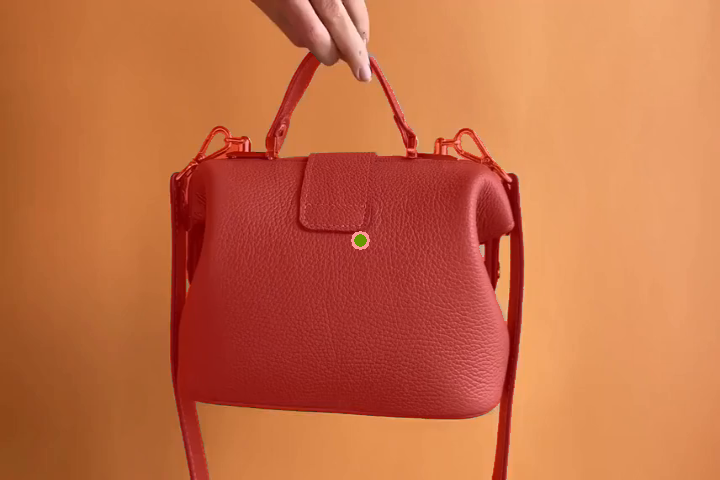

In [9]:
import os
os.chdir('/content/VideoPainter')
os.environ['PYTHONPATH'] = '/content/VideoPainter/diffusers/src:/content/VideoPainter/app'
!python run_demo.py --video "$VP_VIDEO" --click_x $VP_X --click_y $VP_Y --prompt "$VP_PROMPT" --output_dir "$VP_OUTPUT" --sam2_checkpoint ./ckpt/sam2_hiera_large.pt --mask_only

p = f'{OUTPUT_DIR}/frame0_with_mask.png'
if os.path.exists(p):
    from IPython.display import display, Image as I
    display(I(filename=p, width=720))
else:
    print('ERROR: check logs above')

In [11]:
!find /content/VideoPainter/ckpt/VideoPainter -name "config.json" 2>/dev/null

/content/VideoPainter/ckpt/VideoPainter/config.json
/content/VideoPainter/ckpt/VideoPainter/VideoPainter/checkpoints/branch/config.json


In [19]:
path = '/content/VideoPainter/run_demo.py'
with open(path, 'r') as f:
    code = f.read()
code = code.replace('    pipe.vae.enable_tiling()\n', '')
with open(path, 'w') as f:
    f.write(code)
print('Tiling removed!')

Tiling removed!


## Cell 8: Run Inference (A100 ~3-5 min)

In [20]:
import os
os.chdir('/content/VideoPainter')
os.environ['PYTHONPATH'] = '/content/VideoPainter/diffusers/src:/content/VideoPainter/app'
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python run_demo.py \
    --video "$VP_VIDEO" --click_x $VP_X --click_y $VP_Y --prompt "$VP_PROMPT" \
    --output_dir "$VP_OUTPUT" --model_path ./ckpt/CogVideoX-5b-I2V \
    --inpainting_branch ./ckpt/VideoPainter/VideoPainter/checkpoints/branch \
    --sam2_checkpoint ./ckpt/sam2_hiera_large.pt \
    --num_inference_steps $VP_STEPS --guidance_scale $VP_GUIDANCE \
    --seed $VP_SEED --dilate_size $VP_DILATE

[1/5] Loading video: test_videos/0006-handbag1_scene01.mp4
  Original: 77 frames, 24.0 fps, 3.2s
  Extracted: 39 frames at 8fps, 480x720
[2/5] Running SAM2...
self.image_size 1024
Time taken to warm up the visual backbone and cache the image feature on frame 0: 0.54s
  First frame mask: 94350 px (27.3%)
propagate in video: 100% 39/39 [00:36<00:00,  1.08it/s]
  Done! shape: (39, 480, 720)
[3/5] Saving visualization...
[4/5] Running VideoPainter inpainting...
  Prompt: A red leather wallet on a table
  Using 37 frames
  Loading models...
Loading pipeline components...:   0% 0/5 [00:00<?, ?it/s]
Loading weights:   0% 0/219 [00:00<?, ?it/s]
Loading weights:   0% 1/219 [00:00<00:00, 9709.04it/s, Materializing param=encoder.block.0.layer.0.SelfAttention.k.weight]
Loading weights:   0% 1/219 [00:00<00:00, 5190.97it/s, Materializing param=encoder.block.0.layer.0.SelfAttention.k.weight]
Loading weights:   1% 2/219 [00:00<00:00, 4821.04it/s, Materializing param=encoder.block.0.layer.0.SelfAttent

## Cell 9: View Results

--- First ---


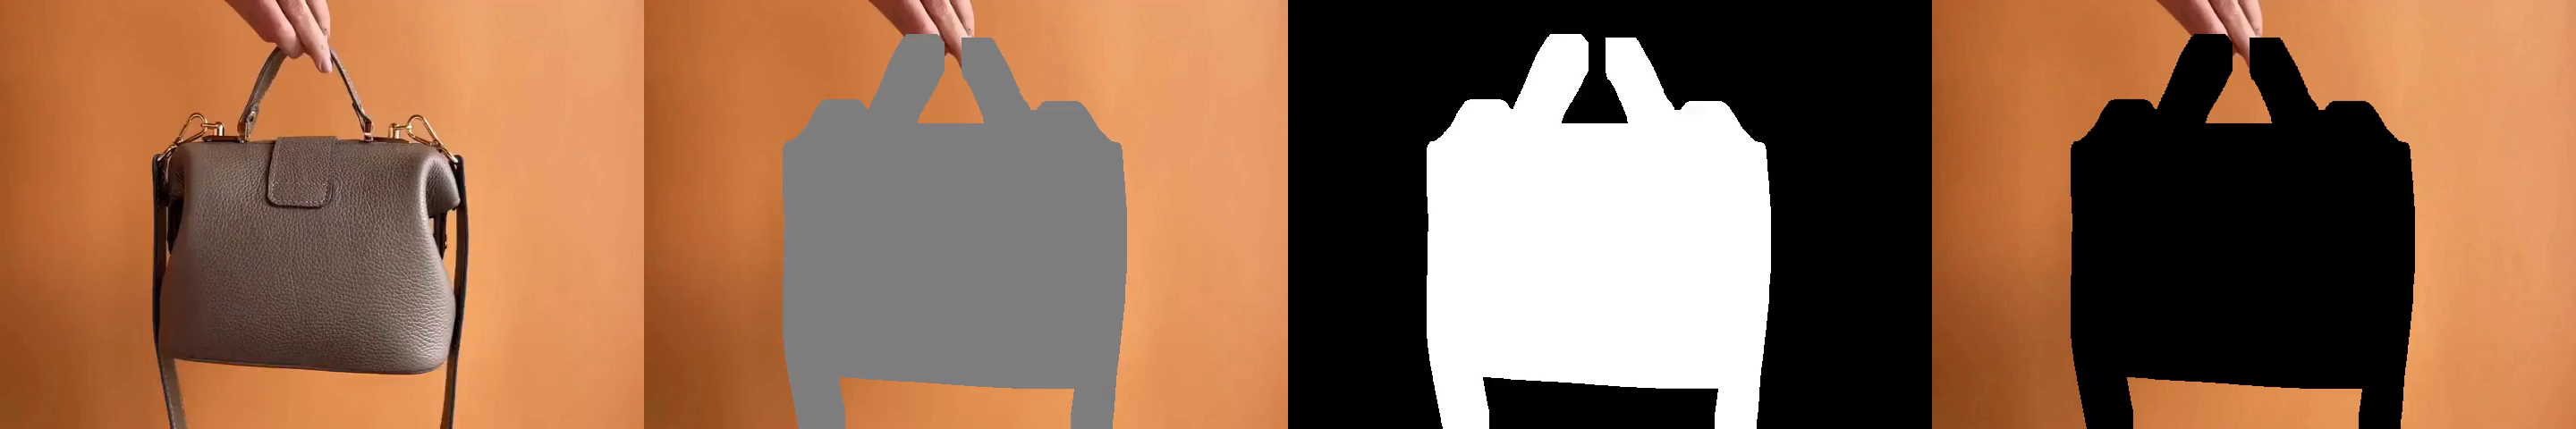

--- Mid ---


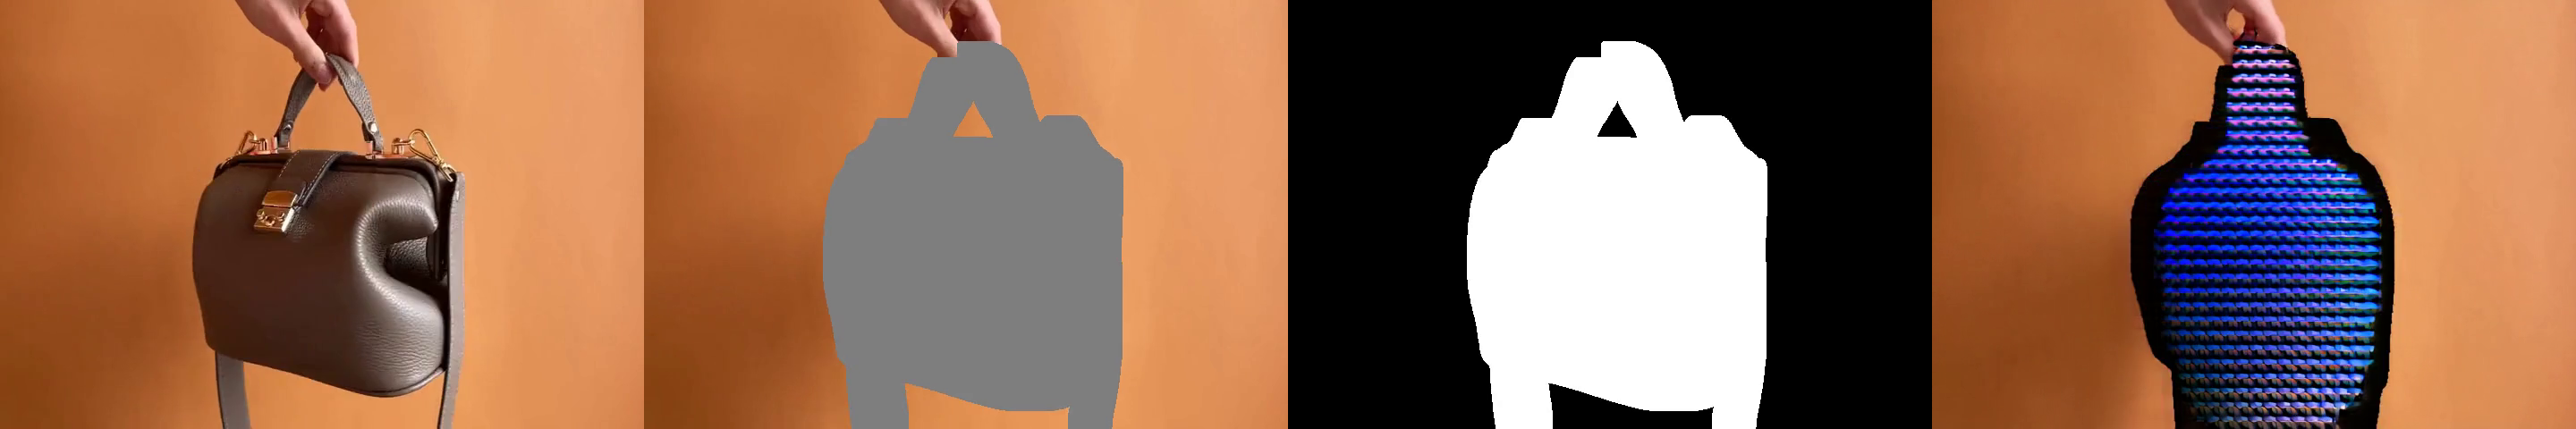

--- Last ---


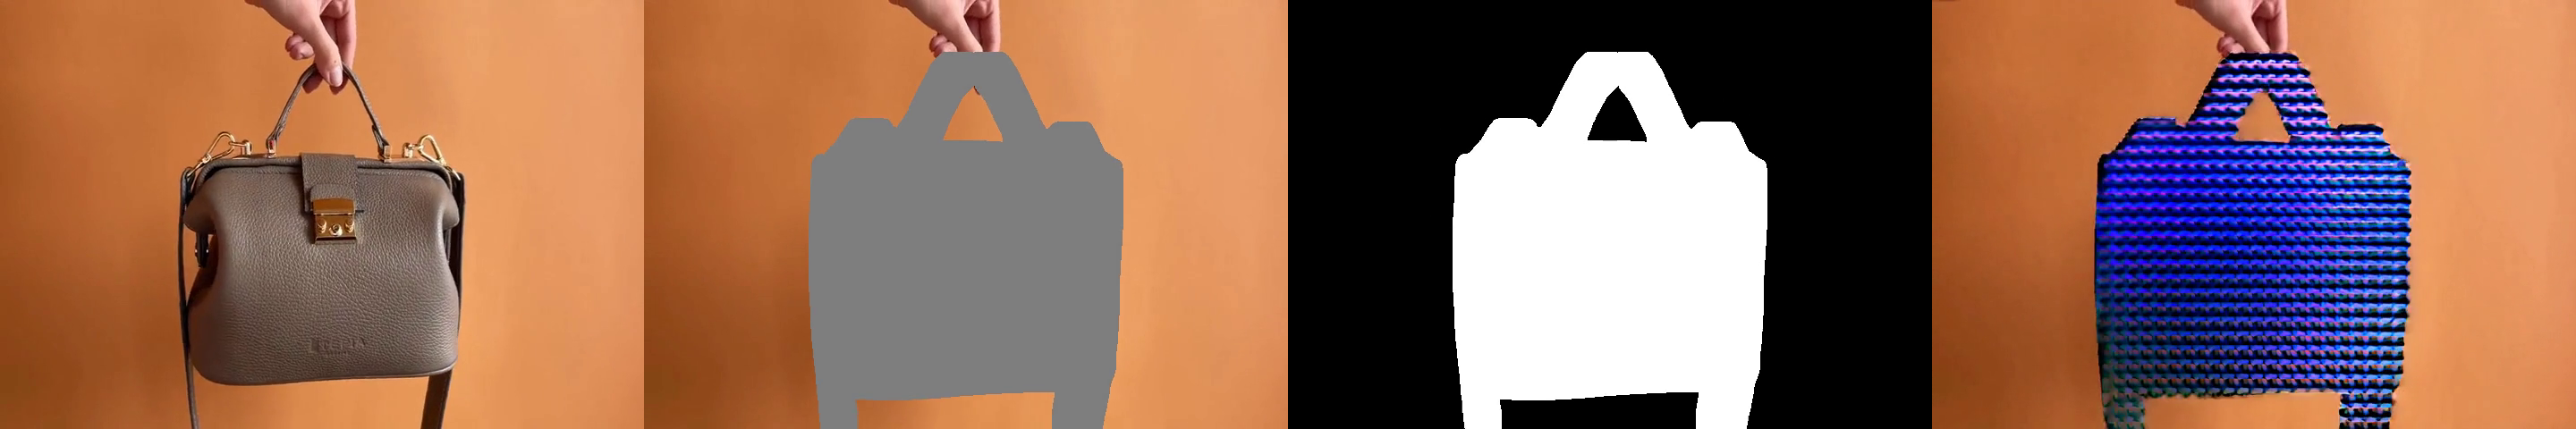


=== Video ===


In [21]:
import cv2
from IPython.display import display, Image as I, Video as V
for src in ['result','result_vis']:
    cap = cv2.VideoCapture(f'{OUTPUT_DIR}/{src}.mp4')
    tot = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    pre = 'frame' if src=='result' else 'vis'
    for nm,ix in [(f'{pre}_first',0),(f'{pre}_mid',tot//2),(f'{pre}_last',tot-1)]:
        cap.set(cv2.CAP_PROP_POS_FRAMES,ix)
        r,f=cap.read()
        if r: cv2.imwrite(f'{OUTPUT_DIR}/{nm}.png',f)
    cap.release()
for lb,fn in [('First','vis_first'),('Mid','vis_mid'),('Last','vis_last')]:
    print(f'--- {lb} ---')
    display(I(filename=f'{OUTPUT_DIR}/{fn}.png',width=1000))
print('\n=== Video ===')
display(V(f'{OUTPUT_DIR}/result.mp4',embed=True,width=720))

## Cell 10: Download

In [22]:
import shutil
shutil.make_archive(f'/content/{OUTPUT_DIR}','zip','.',OUTPUT_DIR)
from google.colab import files
files.download(f'/content/{OUTPUT_DIR}.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
!grep "model_cpu_offload_seq"  /content/VideoPainter/diffusers/src/diffusers/pipelines/cogvideo/pipeline_cogvideox_inpainting_i2v_branch_anyl.py

    model_cpu_offload_seq = "text_encoder->branch->transformer->vae"


In [24]:
!grep "enable_tiling\|enable_slicing" /content/VideoPainter/run_demo.py

    pipe.vae.enable_slicing()


In [25]:
!ls -lh /content/VideoPainter/ckpt/VideoPainter/VideoPainter/checkpoints/branch/

total 680M
-rw-r--r-- 1 root root  926 Apr  6 06:29 config.json
-rw-r--r-- 1 root root 680M Apr  6 06:29 diffusion_pytorch_model.safetensors
